In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import layers , metrics , models , optimizers , preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Importing the data 


In [15]:
dataset_path = r'C:\Users\vjhjh\OneDrive\Bureau\STUDY\LegumesEtFruitsDataset-20240427T141442Z-001'

batch_size = 32
image_size = (224, 224) 
train_dir = r'C:\Users\vjhjh\Downloads\fruitsetlegumes-20240522T012543Z-001\fruitsetlegumes\train'
validation_dir = r'C:\Users\vjhjh\Downloads\fruitsetlegumes-20240522T012543Z-001\fruitsetlegumes\validation'
test_dir = r'C:\Users\vjhjh\Downloads\fruitsetlegumes-20240522T012543Z-001\fruitsetlegumes\test'

train_datagen = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    shear_range =0.2,
    zoom_range = 0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'  )

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 874 images belonging to 14 classes.
Found 252 images belonging to 14 classes.
Found 122 images belonging to 14 classes.


In [16]:
# get the number of classes
num_classes = train_generator.num_classes

class_labels = list(train_generator.class_indices.keys())

# Creating the Model 

In [26]:
fruit_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),  
    layers.Dense(512, activation='relu'),
    layers.Dense(14, activation='softmax')  
])

c:\Users\vjhjh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
fruit_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,270,478 (73.51 MB)

 Trainable params: 19,270,478 (73.51 MB)

 Non-trainable params: 0 (0.00 B)

## fitiing the model 

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint

fruit_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # categorical_crossentropy for multi-class classification

checkpoint = ModelCheckpoint('best_fruit_model.keras', 
                             monitor='val_accuracy', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='max')


history = fruit_model.fit(train_generator, 
                          epochs=30, 
                          validation_data=validation_generator, 
                          callbacks=[checkpoint])

Epoch 1/30


c:\Users\vjhjh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.1307 - loss: 2.5675
Epoch 1: val_accuracy improved from -inf to 0.35714, saving model to best_fruit_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 757ms/step - accuracy: 0.1328 - loss: 2.5604 - val_accuracy: 0.3571 - val_loss: 1.8036
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.4164 - loss: 1.6049
Epoch 2: val_accuracy improved from 0.35714 to 0.53571, saving model to best_fruit_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 22s 721ms/step - accuracy: 0.4169 - loss: 1.6031 - val_accuracy: 0.5357 - val_loss: 1.3470
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.5323 - loss: 1.1949
Epoch 3: val_accuracy improved from 0.53571 to 0.54762, saving model to best_fruit_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 22s 712ms/step - accuracy: 0.5314 - loss: 1.1964 - val_accuracy: 0.5476 - val_loss: 1.1945
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.5761 - loss: 1.0895
Epoch 4: val_accuracy improved 

In [29]:
# # Compile the model
# fruit_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # categorical_crossentropy for multi-class classification

# # Train the fruit_model
# history = fruit_model.fit(train_generator, epochs=9, validation_data=validation_generator)

## Evaluating and saving the model 

In [30]:
# evaluate the model
score = fruit_model.evaluate(test_generator, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
# save the fruit_model
fruit_model.save('fruit_model.h5')

Test loss: 0.323052316904068
Test accuracy: 0.9016393423080444


# Using the Model

In [11]:
import numpy as np
from PIL import Image

In [12]:

# model = keras.models.load_model("fruit_model.h5")
model = keras.models.load_model("best_fruit_model.keras")

In [13]:

directory_path = r'C:\Users\vjhjh\Downloads\fruitsetlegumes-20240522T012543Z-001\fruitsetlegumes\test'

def preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((224, 224))
    image_array = np.array(image) / 255.0  
    image_array = np.expand_dims(image_array, axis=0)  # add batch dimension
    return image_array


# Predict

In [33]:
import random
import os

random_images = random.sample(os.listdir(directory_path), 5)

def get_all_image_paths(directory_path):
    image_paths = []
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'gif')):
                image_paths.append(os.path.join(root, file))
    return image_paths


all_image_paths = get_all_image_paths(directory_path)

# Select 5 random images from all available images
random_images = random.sample(all_image_paths, 5)

images_and_predictions = []

for image_name in random_images:
    image_path = os.path.join(directory_path, image_name)
    image_array = preprocess_image(image_path)
    

    prediction = model.predict(image_array)
    predicted_class = np.argmax(prediction)
    label = class_labels[predicted_class]
    print(label)
    # Store the image and prediction
    images_and_predictions.append((image_path, predicted_class))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Onion
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
HotPeeper
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Cucumber
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Squach
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Squach


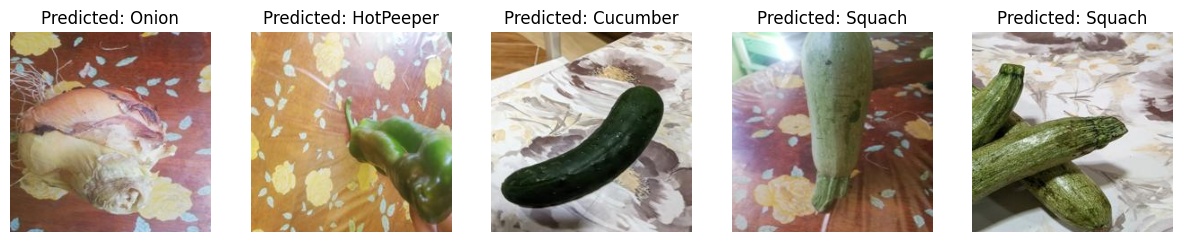

In [34]:
import matplotlib.pyplot as plt
# Plot the images with their predictions
plt.figure(figsize=(15, 10))

for i, (image_path, predicted_class) in enumerate(images_and_predictions):
    image = Image.open(image_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f'Predicted: { class_labels[predicted_class]}')
    plt.axis('off')

plt.show()
